In [11]:
import numpy as np
from scipy.stats import wishart
from geomstats.geometry.spd_matrices import SPDMatrices, SPDLogEuclideanMetric, SPDAffineMetric

from scipy.special import digamma
import matplotlib.pyplot as plt

# Define the matrices from your paper
Sigma_1 = np.array([[1, -0.6],
                   [-0.6, 0.5]])
Sigma_2 = np.array([[1, 0],
                   [0, 1]])
Sigma_3 = np.array([[0.5, 0.4],
                   [0.4, 1]])

def Sigma_t(t_array, Sigma_array):
    """Same interpolation function as in ALL_main_parallel.py"""
    t_array = np.array(t_array)
    t_array = t_array[:, None, None]
    return np.where(np.floor(t_array + 1/2) % 2 == 0, 
                   np.cos(np.pi*t_array)**2 * Sigma_array[0] + (1 - np.cos(np.pi*t_array)**2) * Sigma_array[1], 0) + \
           np.where(np.floor(t_array + 1/2) % 2 == 1, 
                   (1 - np.cos(np.pi*t_array)**2) * Sigma_array[1] + np.cos(np.pi*t_array)**2 * Sigma_array[2], 0)

def experiment_distance_independence(t_values, df=2, n_samples=10000):
    """
    Test if E[d(S, M_0(T))] is independent of T for both AI and LE distances
    """
    # Setup
    q = Sigma_1.shape[0]
    c_dq = 2 * np.exp((1 / q) * sum(digamma((df - np.arange(1, q + 1) + 1) / 2)))
    
    # Initialize distance metrics
    manifold = SPDMatrices(n=q)
    ai_metric = SPDAffineMetric(space=manifold)
    le_metric = SPDLogEuclideanMetric(space=manifold)
    
    results = {
        't_values': t_values,
        'ai_distances': [],
        'le_distances': [],
        'ai_means': [],
        'le_means': [],
        'ai_stds': [],
        'le_stds': []
    }
    
    print("Testing distance independence for AI and LE metrics...")
    print(f"Using {n_samples} Monte Carlo samples per t-value")
    
    for t in t_values:
        print(f"\nTesting t = {t:.2f}")
        
        # Get M_0(t)
        M_0_t = Sigma_t([t], (Sigma_1, Sigma_2, Sigma_3))[0]
        # print(f"M_0({t}) = \n{M_0_t}")
        
        # Generate Wishart samples S | T=t
        ai_distances_t = []
        le_distances_t = []
        
        for i in range(n_samples):
            # Sample S ~ Wishart(df, c_dq^{-1} * M_0(t))
            S = wishart(df=df, scale=M_0_t/c_dq).rvs()
            
            # Compute distances
            d_ai = ai_metric.dist(S, M_0_t)
            d_le = le_metric.dist(S, M_0_t)
            
            ai_distances_t.append(d_ai)
            le_distances_t.append(d_le)
        
        # Store results
        results['ai_distances'].append(ai_distances_t)
        results['le_distances'].append(le_distances_t)
        results['ai_means'].append(np.mean(ai_distances_t))
        results['le_means'].append(np.mean(le_distances_t))
        results['ai_stds'].append(np.std(ai_distances_t))
        results['le_stds'].append(np.std(le_distances_t))
        
        print(f"E[d_AI(S, M_0({t}))] ≈ {results['ai_means'][-1]:.4f} ± {results['ai_stds'][-1]:.4f}")
        print(f"E[d_LE(S, M_0({t}))] ≈ {results['le_means'][-1]:.4f} ± {results['le_stds'][-1]:.4f}")
    
    return results

def plot_results(results):
    """Plot the results to visualize the difference"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    t_values = results['t_values']
    
    # AI distances
    ax1.errorbar(t_values, results['ai_means'], yerr=results['ai_stds'], 
                marker='o', capsize=5, capthick=2, label='AI metric')
    ax1.set_xlabel('t')
    ax1.set_ylabel('E[d(S, M₀(t))]')
    ax1.set_title('Affine-Invariant Distance')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    
    # LE distances
    ax2.errorbar(t_values, results['le_means'], yerr=results['le_stds'], 
                marker='s', capsize=5, capthick=2, label='LE metric', color='red')
    ax2.set_xlabel('t')
    ax2.set_ylabel('E[d(S, M₀(t))]')
    ax2.set_title('Log-Euclidean Distance')
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    
    plt.tight_layout()
    plt.show()

def statistical_test(results):
    """Perform statistical tests to check if means are significantly different"""
    from scipy.stats import f_oneway
    
    print("\n" + "="*60)
    print("STATISTICAL ANALYSIS")
    print("="*60)
    
    # Test for AI metric
    ai_pvalue = f_oneway(*results['ai_distances'])[1]
    print(f"AI metric - One-way ANOVA p-value: {ai_pvalue:.6f}")
    if ai_pvalue > 0.05:
        print("AI: No significant difference between t-values (expected)")
    else:
        print("AI: Significant differences found (unexpected)")
    
    # Test for LE metric
    le_pvalue = f_oneway(*results['le_distances'])[1]
    print(f"LE metric - One-way ANOVA p-value: {le_pvalue:.6f}")
    if le_pvalue < 0.05:
        print("LE: Significant differences found")
    else:
        print("LE: No significant difference")
    
    # Show specific comparisons
    # Calculate relative differences
    #ai_rel_diff = abs(results['ai_means'][-1] - results['ai_means'][0]) / results['ai_means'][0] * 100
    #le_rel_diff = abs(results['le_means'][-1] - results['le_means'][0]) / results['le_means'][0] * 100
    
    #print(f"\nRelative differences:")
    #print(f"AI metric: {ai_rel_diff:.2f}% difference")
    #print(f"LE metric: {le_rel_diff:.2f}% difference")

# Run the experiment
if __name__ == "__main__":
    # Test at several t values, focusing on t=0 and t=1
    t_test_values = list(np.linspace(0, 2, 21))  # 0, 0.1, ..., 1.0
    
    # Run experiment
    results = experiment_distance_independence(t_test_values, df=2, n_samples=10000)
    
    # Analyze results
    plot_results(results)
    statistical_test(results)



Testing distance independence for AI and LE metrics...
Using 10000 Monte Carlo samples per t-value

Testing t = 0.00
E[d_AI(S, M_0(0.0))] ≈ 2.7880 ± 1.6773
E[d_LE(S, M_0(0.0))] ≈ 2.6187 ± 1.6176

Testing t = 0.10
E[d_AI(S, M_0(0.1))] ≈ 2.7575 ± 1.5900
E[d_LE(S, M_0(0.1))] ≈ 2.6527 ± 1.5523

Testing t = 0.20


KeyboardInterrupt: 

Testing distance independence for AI and LE metrics...
Using 10000 Monte Carlo samples per t-value

Testing t = 0.00
E[d_AI(S, M_0(0.0))] ≈ 2.8110 ± 1.6660
E[d_LE(S, M_0(0.0))] ≈ 2.6395 ± 1.6076

Testing t = 0.10
E[d_AI(S, M_0(0.1))] ≈ 2.7893 ± 1.6703
E[d_LE(S, M_0(0.1))] ≈ 2.6843 ± 1.6332

Testing t = 0.20
E[d_AI(S, M_0(0.2))] ≈ 2.7808 ± 1.6519
E[d_LE(S, M_0(0.2))] ≈ 2.7447 ± 1.6383

Testing t = 0.30
E[d_AI(S, M_0(0.30000000000000004))] ≈ 2.7857 ± 1.6652
E[d_LE(S, M_0(0.30000000000000004))] ≈ 2.7781 ± 1.6623

Testing t = 0.40
E[d_AI(S, M_0(0.4))] ≈ 2.7650 ± 1.6304
E[d_LE(S, M_0(0.4))] ≈ 2.7646 ± 1.6302

Testing t = 0.50
E[d_AI(S, M_0(0.5))] ≈ 2.7870 ± 1.6136
E[d_LE(S, M_0(0.5))] ≈ 2.7870 ± 1.6136

Testing t = 0.60
E[d_AI(S, M_0(0.6000000000000001))] ≈ 2.8054 ± 1.6654
E[d_LE(S, M_0(0.6000000000000001))] ≈ 2.8051 ± 1.6653

Testing t = 0.70
E[d_AI(S, M_0(0.7000000000000001))] ≈ 2.7929 ± 1.6451
E[d_LE(S, M_0(0.7000000000000001))] ≈ 2.7890 ± 1.6436

Testing t = 0.80
E[d_AI(S, M_0(0.8))] ≈ 

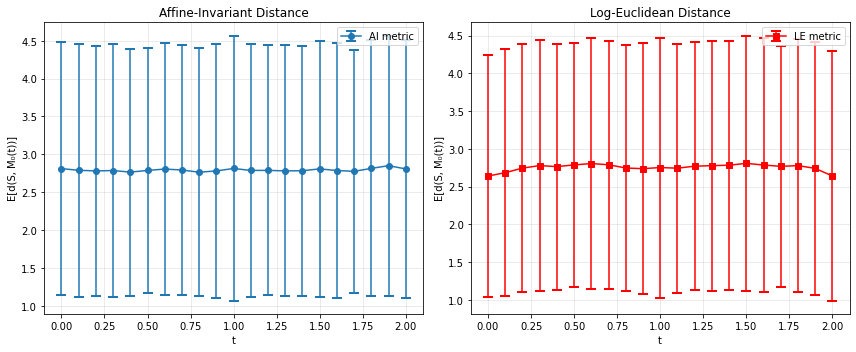


STATISTICAL ANALYSIS

--- NORMALITY TESTS (AI METRIC) ---
t=0.00: Shapiro-Wilk p=0.0000 ✗
t=0.10: Shapiro-Wilk p=0.0000 ✗
t=0.20: Shapiro-Wilk p=0.0000 ✗
t=0.30: Shapiro-Wilk p=0.0000 ✗
t=0.40: Shapiro-Wilk p=0.0000 ✗
t=0.50: Shapiro-Wilk p=0.0000 ✗
t=0.60: Shapiro-Wilk p=0.0000 ✗
t=0.70: Shapiro-Wilk p=0.0000 ✗
t=0.80: Shapiro-Wilk p=0.0000 ✗
t=0.90: Shapiro-Wilk p=0.0000 ✗
t=1.00: Shapiro-Wilk p=0.0000 ✗
t=1.10: Shapiro-Wilk p=0.0000 ✗
t=1.20: Shapiro-Wilk p=0.0000 ✗
t=1.30: Shapiro-Wilk p=0.0000 ✗
t=1.40: Shapiro-Wilk p=0.0000 ✗
t=1.50: Shapiro-Wilk p=0.0000 ✗
t=1.60: Shapiro-Wilk p=0.0000 ✗
t=1.70: Shapiro-Wilk p=0.0000 ✗
t=1.80: Shapiro-Wilk p=0.0000 ✗
t=1.90: Shapiro-Wilk p=0.0000 ✗
t=2.00: Shapiro-Wilk p=0.0000 ✗

--- NORMALITY TESTS (LE METRIC) ---
t=0.00: Shapiro-Wilk p=0.0000 ✗
t=0.10: Shapiro-Wilk p=0.0000 ✗
t=0.20: Shapiro-Wilk p=0.0000 ✗
t=0.30: Shapiro-Wilk p=0.0000 ✗
t=0.40: Shapiro-Wilk p=0.0000 ✗
t=0.50: Shapiro-Wilk p=0.0000 ✗
t=0.60: Shapiro-Wilk p=0.0000 ✗
t=0.70: 

/Users/Diego/miniconda3/envs/pballs/lib/python3.9/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 10000.
  res = hypotest_fun_out(*samples, **kwds)


AI metric - Kruskal-Wallis p-value: 0.073414
LE metric - Kruskal-Wallis p-value: 0.000000


In [3]:
def statistical_test(results):
    """Perform statistical tests to check if means are significantly different"""
    from scipy.stats import f_oneway, shapiro, levene
    
    print("\n" + "="*60)
    print("STATISTICAL ANALYSIS")
    print("="*60)
    
    # Check normality assumptions for AI metric
    print("\n--- NORMALITY TESTS (AI METRIC) ---")
    ai_normality_violations = 0
    for i, distances in enumerate(results['ai_distances']):
        if len(distances) >= 3:  # Minimum for Shapiro-Wilk
            stat, pval = shapiro(distances)
            normal = pval > 0.05
            print(f"t={results['t_values'][i]:.2f}: Shapiro-Wilk p={pval:.4f} {'✓' if normal else '✗'}")
            if not normal:
                ai_normality_violations += 1
        else:
            print(f"t={results['t_values'][i]:.2f}: Sample too small for normality test")
    
    # Check normality assumptions for LE metric
    print("\n--- NORMALITY TESTS (LE METRIC) ---")
    le_normality_violations = 0
    for i, distances in enumerate(results['le_distances']):
        if len(distances) >= 3:  # Minimum for Shapiro-Wilk
            stat, pval = shapiro(distances)
            normal = pval > 0.05
            print(f"t={results['t_values'][i]:.2f}: Shapiro-Wilk p={pval:.4f} {'✓' if normal else '✗'}")
            if not normal:
                le_normality_violations += 1
        else:
            print(f"t={results['t_values'][i]:.2f}: Sample too small for normality test")
    
    # Check equal variances (Levene's test)
    print("\n--- EQUAL VARIANCE TESTS ---")
    try:
        ai_levene_stat, ai_levene_pval = levene(*results['ai_distances'])
        le_levene_stat, le_levene_pval = levene(*results['le_distances'])
        
        print(f"AI metric - Levene's test p-value: {ai_levene_pval:.6f} {'✓' if ai_levene_pval > 0.05 else '✗'}")
        print(f"LE metric - Levene's test p-value: {le_levene_pval:.6f} {'✓' if le_levene_pval > 0.05 else '✗'}")
    except Exception as e:
        print(f"Could not perform Levene's test: {e}")
        ai_levene_pval = le_levene_pval = 1.0  # Assume equal variances if test fails
    
    # Summary of assumption violations
    print(f"\n--- ASSUMPTION SUMMARY ---")
    print(f"AI metric: {ai_normality_violations}/{len(results['ai_distances'])} groups violated normality")
    print(f"LE metric: {le_normality_violations}/{len(results['le_distances'])} groups violated normality")
    print(f"AI metric: Equal variances {'assumed' if ai_levene_pval > 0.05 else 'violated'}")
    print(f"LE metric: Equal variances {'assumed' if le_levene_pval > 0.05 else 'violated'}")
    
    # Provide recommendations
    print(f"\n--- RECOMMENDATIONS ---")
    if ai_normality_violations > len(results['ai_distances']) * 0.3:  # More than 30% violations
        print("AI: Consider non-parametric Kruskal-Wallis test due to normality violations")
    elif ai_levene_pval <= 0.05:
        print("AI: Consider Welch's ANOVA due to unequal variances")
    else:
        print("AI: Standard one-way ANOVA assumptions appear satisfied")
        
    if le_normality_violations > len(results['le_distances']) * 0.3:  # More than 30% violations
        print("LE: Consider non-parametric Kruskal-Wallis test due to normality violations")
    elif le_levene_pval <= 0.05:
        print("LE: Consider Welch's ANOVA due to unequal variances")
    else:
        print("LE: Standard one-way ANOVA assumptions appear satisfied")
    
    # Perform ANOVA tests
    print(f"\n--- ANOVA RESULTS ---")
    
    # Test for AI metric
    ai_pvalue = f_oneway(*results['ai_distances'])[1]
    print(f"AI metric - One-way ANOVA p-value: {ai_pvalue:.6f}")
    if ai_pvalue > 0.05:
        print("AI: No significant difference between t-values (expected)")
    else:
        print("AI: Significant differences found (unexpected)")
    
    # Test for LE metric
    le_pvalue = f_oneway(*results['le_distances'])[1]
    print(f"LE metric - One-way ANOVA p-value: {le_pvalue:.6f}")
    if le_pvalue < 0.05:
        print("LE: Significant differences found")
    else:
        print("LE: No significant difference")
    
    # Alternative non-parametric test if needed
    if (ai_normality_violations > len(results['ai_distances']) * 0.3 or 
        le_normality_violations > len(results['le_distances']) * 0.3):
        
        from scipy.stats import kruskal
        print(f"\n--- NON-PARAMETRIC ALTERNATIVE (Kruskal-Wallis) ---")
        
        ai_kruskal_stat, ai_kruskal_pval = kruskal(*results['ai_distances'])
        le_kruskal_stat, le_kruskal_pval = kruskal(*results['le_distances'])
        
        print(f"AI metric - Kruskal-Wallis p-value: {ai_kruskal_pval:.6f}")
        print(f"LE metric - Kruskal-Wallis p-value: {le_kruskal_pval:.6f}")

# Run the experiment
if __name__ == "__main__":
    # Test at several t values, focusing on t=0 and t=1
    t_test_values = list(np.linspace(0, 2, 21))  # 0, 0.1, ..., 1.0
    
    # Run experiment
    results = experiment_distance_independence(t_test_values, df=2, n_samples=10000)
    
    # Analyze results
    plot_results(results)
    statistical_test(results)

Testing distance independence for AI and LE metrics...
Using 10000 Monte Carlo samples per t-value

Testing t = 0.00
E[d_AI(S, M_0(0.0))] ≈ 2.7787 ± 1.6503
E[d_LE(S, M_0(0.0))] ≈ 2.6093 ± 1.5912

Testing t = 0.20
E[d_AI(S, M_0(0.2))] ≈ 2.7851 ± 1.6488
E[d_LE(S, M_0(0.2))] ≈ 2.7487 ± 1.6354

Testing t = 0.40
E[d_AI(S, M_0(0.4))] ≈ 2.7952 ± 1.6736
E[d_LE(S, M_0(0.4))] ≈ 2.7947 ± 1.6734

Testing t = 0.60
E[d_AI(S, M_0(0.6000000000000001))] ≈ 2.7888 ± 1.7281
E[d_LE(S, M_0(0.6000000000000001))] ≈ 2.7885 ± 1.7280

Testing t = 0.80
E[d_AI(S, M_0(0.8))] ≈ 2.8157 ± 1.6940
E[d_LE(S, M_0(0.8))] ≈ 2.7978 ± 1.6874

Testing t = 1.00
E[d_AI(S, M_0(1.0))] ≈ 2.8148 ± 1.6638
E[d_LE(S, M_0(1.0))] ≈ 2.7526 ± 1.6410

Testing t = 1.20
E[d_AI(S, M_0(1.2000000000000002))] ≈ 2.8232 ± 1.7544
E[d_LE(S, M_0(1.2000000000000002))] ≈ 2.8053 ± 1.7475

Testing t = 1.40
E[d_AI(S, M_0(1.4000000000000001))] ≈ 2.7803 ± 1.6481
E[d_LE(S, M_0(1.4000000000000001))] ≈ 2.7800 ± 1.6480

Testing t = 1.60
E[d_AI(S, M_0(1.6))] ≈ 2.

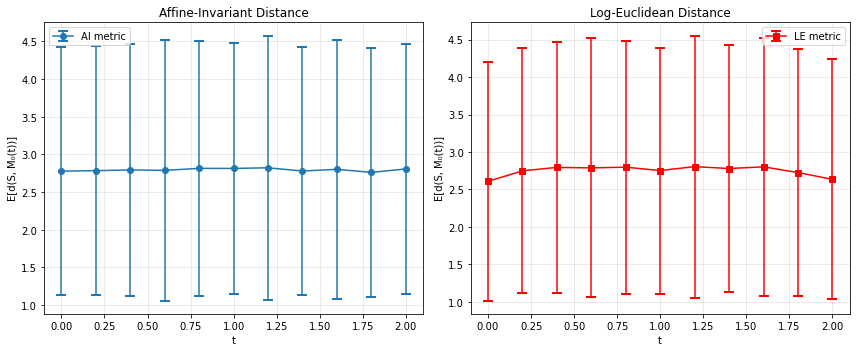


STATISTICAL ANALYSIS

--- NORMALITY TESTS (AI METRIC) ---
t=0.00: Shapiro-Wilk p=0.0000 ✗
t=0.20: Shapiro-Wilk p=0.0000 ✗
t=0.40: Shapiro-Wilk p=0.0000 ✗
t=0.60: Shapiro-Wilk p=0.0000 ✗
t=0.80: Shapiro-Wilk p=0.0000 ✗
t=1.00: Shapiro-Wilk p=0.0000 ✗
t=1.20: Shapiro-Wilk p=0.0000 ✗
t=1.40: Shapiro-Wilk p=0.0000 ✗
t=1.60: Shapiro-Wilk p=0.0000 ✗
t=1.80: Shapiro-Wilk p=0.0000 ✗
t=2.00: Shapiro-Wilk p=0.0000 ✗

--- NORMALITY TESTS (LE METRIC) ---
t=0.00: Shapiro-Wilk p=0.0000 ✗
t=0.20: Shapiro-Wilk p=0.0000 ✗
t=0.40: Shapiro-Wilk p=0.0000 ✗
t=0.60: Shapiro-Wilk p=0.0000 ✗
t=0.80: Shapiro-Wilk p=0.0000 ✗
t=1.00: Shapiro-Wilk p=0.0000 ✗
t=1.20: Shapiro-Wilk p=0.0000 ✗
t=1.40: Shapiro-Wilk p=0.0000 ✗
t=1.60: Shapiro-Wilk p=0.0000 ✗
t=1.80: Shapiro-Wilk p=0.0000 ✗
t=2.00: Shapiro-Wilk p=0.0000 ✗

--- ASSUMPTION SUMMARY ---
AI metric: 11/11 groups violated normality
LE metric: 11/11 groups violated normality

--- PRIMARY ANALYSIS: KRUSKAL-WALLIS TEST (Non-parametric) ---
Using Kruskal-Wallis d

In [ ]:
def statistical_test(results):
    """Perform statistical tests to check if means are significantly different"""
    from scipy.stats import f_oneway, shapiro, levene, kruskal
    
    print("\n" + "="*60)
    print("STATISTICAL ANALYSIS")
    print("="*60)
    
    # Check normality assumptions for AI metric
    print("\n--- NORMALITY TESTS (AI METRIC) ---")
    ai_normality_violations = 0
    for i, distances in enumerate(results['ai_distances']):
        if len(distances) >= 3:  # Minimum for Shapiro-Wilk
            stat, pval = shapiro(distances)
            normal = pval > 0.05
            print(f"t={results['t_values'][i]:.2f}: Shapiro-Wilk p={pval:.4f} {'✓' if normal else '✗'}")
            if not normal:
                ai_normality_violations += 1
        else:
            print(f"t={results['t_values'][i]:.2f}: Sample too small for normality test")
    
    # Check normality assumptions for LE metric
    print("\n--- NORMALITY TESTS (LE METRIC) ---")
    le_normality_violations = 0
    for i, distances in enumerate(results['le_distances']):
        if len(distances) >= 3:  # Minimum for Shapiro-Wilk
            stat, pval = shapiro(distances)
            normal = pval > 0.05
            print(f"t={results['t_values'][i]:.2f}: Shapiro-Wilk p={pval:.4f} {'✓' if normal else '✗'}")
            if not normal:
                le_normality_violations += 1
        else:
            print(f"t={results['t_values'][i]:.2f}: Sample too small for normality test")
    
    # Summary of assumption violations
    print(f"\n--- ASSUMPTION SUMMARY ---")
    print(f"AI metric: {ai_normality_violations}/{len(results['ai_distances'])} groups violated normality")
    print(f"LE metric: {le_normality_violations}/{len(results['le_distances'])} groups violated normality")
    
    # Determine which test to use
    use_nonparametric = (ai_normality_violations > len(results['ai_distances']) * 0.3 or 
                        le_normality_violations > len(results['le_distances']) * 0.3)
    
    if use_nonparametric:
        print(f"\n--- PRIMARY ANALYSIS: KRUSKAL-WALLIS TEST (Non-parametric) ---")
        print("Using Kruskal-Wallis due to normality violations")
        
        # Kruskal-Wallis tests
        ai_kruskal_stat, ai_kruskal_pval = kruskal(*results['ai_distances'])
        le_kruskal_stat, le_kruskal_pval = kruskal(*results['le_distances'])
        
        print(f"AI metric - Kruskal-Wallis statistic: {ai_kruskal_stat:.4f}")
        print(f"AI metric - Kruskal-Wallis p-value: {ai_kruskal_pval:.6f}")
        if ai_kruskal_pval > 0.05:
            print("AI: No significant difference between t-values (expected for affine-invariant)")
        else:
            print("AI: Significant differences found (unexpected)")
            
        print(f"\nLE metric - Kruskal-Wallis statistic: {le_kruskal_stat:.4f}")
        print(f"LE metric - Kruskal-Wallis p-value: {le_kruskal_pval:.6f}")
        if le_kruskal_pval < 0.05:
            print("LE: Significant differences found (expected for log-Euclidean)")
        else:
            print("LE: No significant difference")
            
        # Show ANOVA for comparison (but note it's not reliable)
        print(f"\n--- COMPARISON: ANOVA RESULTS (Not reliable due to normality violations) ---")
        ai_anova_pvalue = f_oneway(*results['ai_distances'])[1]
        le_anova_pvalue = f_oneway(*results['le_distances'])[1]
        print(f"AI metric - ANOVA p-value: {ai_anova_pvalue:.6f} (unreliable)")
        print(f"LE metric - ANOVA p-value: {le_anova_pvalue:.6f} (unreliable)")
        
    else:
        # Standard ANOVA if assumptions are met
        print(f"\n--- PRIMARY ANALYSIS: ONE-WAY ANOVA (Parametric) ---")
        print("ANOVA assumptions appear satisfied")
        
        ai_pvalue = f_oneway(*results['ai_distances'])[1]
        le_pvalue = f_oneway(*results['le_distances'])[1]
        
        print(f"AI metric - One-way ANOVA p-value: {ai_pvalue:.6f}")
        print(f"LE metric - One-way ANOVA p-value: {le_pvalue:.6f}")
    
    # Summary interpretation
    print(f"\n--- INTERPRETATION ---")
    if use_nonparametric:
        if ai_kruskal_pval > 0.05:
            print("✓ AI metric: Distance is independent of t-value (as expected)")
        else:
            print("✗ AI metric: Distance depends on t-value (unexpected)")
            
        if le_kruskal_pval < 0.05:
            print("✓ LE metric: Distance depends on t-value (as expected)")
        else:
            print("✗ LE metric: Distance is independent of t-value (unexpected)")
    else:
        # Similar logic for ANOVA if used
        pass

# Run the experiment
if __name__ == "__main__":
    # Test at several t values, focusing on t=0 and t=1
    t_test_values = list(np.linspace(0, 2, 11))  # 0, 0.1, ..., 1.0
    
    # Run experiment
    results = experiment_distance_independence(t_test_values, df=2, n_samples=10000)
    
    # Analyze results
    plot_results(results)
    statistical_test(results)

In [ ]:
# Add this import at the top
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), os.pardir)))
sys.path.append(os.getcwd())
from pyfrechet.metric_spaces.log_cholesky import LogCholesky, spd_to_log_chol

def statistical_test(results):
    """Perform statistical tests to check if means are significantly different"""
    from scipy.stats import f_oneway, shapiro, levene, kruskal
    
    print("\n" + "="*60)
    print("STATISTICAL ANALYSIS")
    print("="*60)
    
    # Check normality assumptions for AI metric
    print("\n--- NORMALITY TESTS (AI METRIC) ---")
    ai_normality_violations = 0
    for i, distances in enumerate(results['ai_distances']):
        if len(distances) >= 3:  # Minimum for Shapiro-Wilk
            stat, pval = shapiro(distances)
            normal = pval > 0.05
            print(f"t={results['t_values'][i]:.2f}: Shapiro-Wilk p={pval:.4f} {'✓' if normal else '✗'}")
            if not normal:
                ai_normality_violations += 1
        else:
            print(f"t={results['t_values'][i]:.2f}: Sample too small for normality test")
    
    # Check normality assumptions for LE metric
    print("\n--- NORMALITY TESTS (LE METRIC) ---")
    le_normality_violations = 0
    for i, distances in enumerate(results['le_distances']):
        if len(distances) >= 3:  # Minimum for Shapiro-Wilk
            stat, pval = shapiro(distances)
            normal = pval > 0.05
            print(f"t={results['t_values'][i]:.2f}: Shapiro-Wilk p={pval:.4f} {'✓' if normal else '✗'}")
            if not normal:
                le_normality_violations += 1
        else:
            print(f"t={results['t_values'][i]:.2f}: Sample too small for normality test")
    
    # Summary of assumption violations
    print(f"\n--- ASSUMPTION SUMMARY ---")
    print(f"AI metric: {ai_normality_violations}/{len(results['ai_distances'])} groups violated normality")
    print(f"LE metric: {le_normality_violations}/{len(results['le_distances'])} groups violated normality")
    
    # Determine which test to use
    use_nonparametric = (ai_normality_violations > len(results['ai_distances']) * 0.3 or 
                        le_normality_violations > len(results['le_distances']) * 0.3)
    
    if use_nonparametric:
        print(f"\n--- PRIMARY ANALYSIS: KRUSKAL-WALLIS TEST (Non-parametric) ---")
        print("Using Kruskal-Wallis due to normality violations")
        
        # Kruskal-Wallis tests
        ai_kruskal_stat, ai_kruskal_pval = kruskal(*results['ai_distances'])
        le_kruskal_stat, le_kruskal_pval = kruskal(*results['le_distances'])
        
        print(f"AI metric - Kruskal-Wallis statistic: {ai_kruskal_stat:.4f}")
        print(f"AI metric - Kruskal-Wallis p-value: {ai_kruskal_pval:.6f}")
        if ai_kruskal_pval > 0.05:
            print("AI: No significant difference between t-values (expected for affine-invariant)")
        else:
            print("AI: Significant differences found (unexpected)")
            
        print(f"\nLE metric - Kruskal-Wallis statistic: {le_kruskal_stat:.4f}")
        print(f"LE metric - Kruskal-Wallis p-value: {le_kruskal_pval:.6f}")
        if le_kruskal_pval < 0.05:
            print("LE: Significant differences found (expected for log-Euclidean)")
        else:
            print("LE: No significant difference")
            
        # Show ANOVA for comparison (but note it's not reliable)
        print(f"\n--- COMPARISON: ANOVA RESULTS (Not reliable due to normality violations) ---")
        ai_anova_pvalue = f_oneway(*results['ai_distances'])[1]
        le_anova_pvalue = f_oneway(*results['le_distances'])[1]
        print(f"AI metric - ANOVA p-value: {ai_anova_pvalue:.6f} (unreliable)")
        print(f"LE metric - ANOVA p-value: {le_anova_pvalue:.6f} (unreliable)")
        
    else:
        # Standard ANOVA if assumptions are met
        print(f"\n--- PRIMARY ANALYSIS: ONE-WAY ANOVA (Parametric) ---")
        print("ANOVA assumptions appear satisfied")
        
        ai_pvalue = f_oneway(*results['ai_distances'])[1]
        le_pvalue = f_oneway(*results['le_distances'])[1]
        
        print(f"AI metric - One-way ANOVA p-value: {ai_pvalue:.6f}")
        print(f"LE metric - One-way ANOVA p-value: {le_pvalue:.6f}")
    
    # Summary interpretation
    print(f"\n--- INTERPRETATION ---")
    if use_nonparametric:
        if ai_kruskal_pval > 0.05:
            print("✓ AI metric: Distance is independent of t-value (as expected)")
        else:
            print("✗ AI metric: Distance depends on t-value (unexpected)")
            
        if le_kruskal_pval < 0.05:
            print("✓ LE metric: Distance depends on t-value (as expected)")
        else:
            print("✗ LE metric: Distance is independent of t-value (unexpected)")
    else:
        # Similar logic for ANOVA if used
        pass

# Run the experiment
if __name__ == "__main__":
    # Test at several t values, focusing on t=0 and t=1
    t_test_values = list(np.linspace(0, 2, 11))  # 0, 0.1, ..., 1.0
    
    # Run experiment
    results = experiment_distance_independence(t_test_values, df=2, n_samples=10000)
    
    # Analyze results
    plot_results(results)
    statistical_test(results)

Testing distance independence for AI, LE, and Log-Cholesky metrics...
Using 10000 Monte Carlo samples per t-value

Testing t = 0.00
E[d_AI(S, M_0(0.0))] ≈ 2.7952 ± 1.7328
E[d_LE(S, M_0(0.0))] ≈ 2.6262 ± 1.6610
E[d_LC(S, M_0(0.0))] ≈ 1.3866 ± 0.8297

Testing t = 0.20
E[d_AI(S, M_0(0.2))] ≈ 2.7859 ± 1.6794
E[d_LE(S, M_0(0.2))] ≈ 2.7494 ± 1.6661
E[d_LC(S, M_0(0.2))] ≈ 1.5205 ± 0.8266

Testing t = 0.40
E[d_AI(S, M_0(0.4))] ≈ 2.7872 ± 1.6527
E[d_LE(S, M_0(0.4))] ≈ 2.7867 ± 1.6525
E[d_LC(S, M_0(0.4))] ≈ 1.6792 ± 0.8652

Testing t = 0.60
E[d_AI(S, M_0(0.6000000000000001))] ≈ 2.7997 ± 1.6743
E[d_LE(S, M_0(0.6000000000000001))] ≈ 2.7994 ± 1.6742
E[d_LC(S, M_0(0.6000000000000001))] ≈ 1.7005 ± 0.8884

Testing t = 0.80
E[d_AI(S, M_0(0.8))] ≈ 2.8184 ± 1.7131
E[d_LE(S, M_0(0.8))] ≈ 2.8006 ± 1.7065
E[d_LC(S, M_0(0.8))] ≈ 1.6905 ± 0.8986

Testing t = 1.00
E[d_AI(S, M_0(1.0))] ≈ 2.8199 ± 1.6863
E[d_LE(S, M_0(1.0))] ≈ 2.7584 ± 1.6638
E[d_LC(S, M_0(1.0))] ≈ 1.6524 ± 0.8786

Testing t = 1.20
E[d_AI(S, M_0

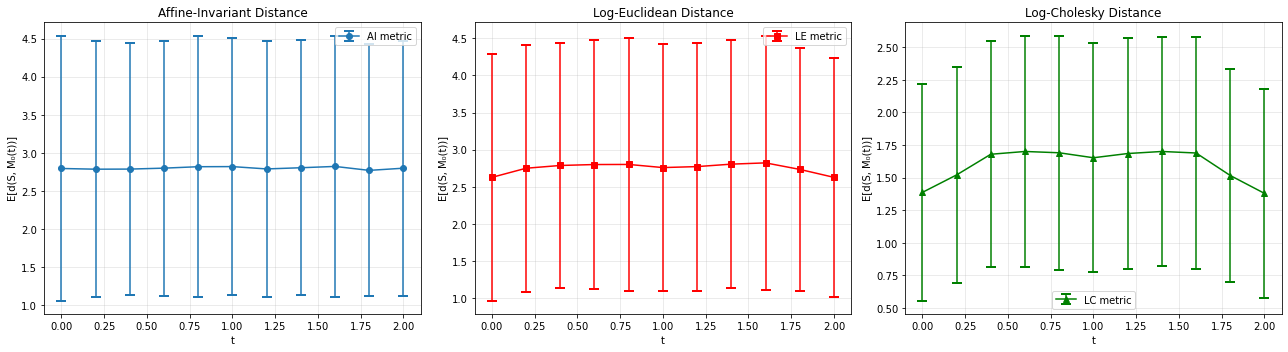


STATISTICAL ANALYSIS

--- NORMALITY TESTS (AI METRIC) ---
t=0.00: Shapiro-Wilk p=0.0000 ✗
t=0.20: Shapiro-Wilk p=0.0000 ✗
t=0.40: Shapiro-Wilk p=0.0000 ✗
t=0.60: Shapiro-Wilk p=0.0000 ✗
t=0.80: Shapiro-Wilk p=0.0000 ✗
t=1.00: Shapiro-Wilk p=0.0000 ✗
t=1.20: Shapiro-Wilk p=0.0000 ✗
t=1.40: Shapiro-Wilk p=0.0000 ✗
t=1.60: Shapiro-Wilk p=0.0000 ✗
t=1.80: Shapiro-Wilk p=0.0000 ✗
t=2.00: Shapiro-Wilk p=0.0000 ✗

--- NORMALITY TESTS (LE METRIC) ---
t=0.00: Shapiro-Wilk p=0.0000 ✗
t=0.20: Shapiro-Wilk p=0.0000 ✗
t=0.40: Shapiro-Wilk p=0.0000 ✗
t=0.60: Shapiro-Wilk p=0.0000 ✗
t=0.80: Shapiro-Wilk p=0.0000 ✗
t=1.00: Shapiro-Wilk p=0.0000 ✗
t=1.20: Shapiro-Wilk p=0.0000 ✗
t=1.40: Shapiro-Wilk p=0.0000 ✗
t=1.60: Shapiro-Wilk p=0.0000 ✗
t=1.80: Shapiro-Wilk p=0.0000 ✗
t=2.00: Shapiro-Wilk p=0.0000 ✗

--- NORMALITY TESTS (LOG-CHOLESKY METRIC) ---
t=0.00: Shapiro-Wilk p=0.0000 ✗
t=0.20: Shapiro-Wilk p=0.0000 ✗
t=0.40: Shapiro-Wilk p=0.0000 ✗
t=0.60: Shapiro-Wilk p=0.0000 ✗
t=0.80: Shapiro-Wilk p=0.

/Users/Diego/miniconda3/envs/pballs/lib/python3.9/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 10000.
  res = hypotest_fun_out(*samples, **kwds)


In [13]:
def experiment_distance_independence(t_values, df=2, n_samples=10000):
    """
    Test if E[d(S, M_0(T))] is independent of T for AI, LE, and Log-Cholesky distances
    """
    # Setup
    q = Sigma_1.shape[0]
    c_dq = 2 * np.exp((1 / q) * sum(digamma((df - np.arange(1, q + 1) + 1) / 2)))
    
    # Initialize distance metrics
    manifold = SPDMatrices(n=q)
    ai_metric = SPDAffineMetric(space=manifold)
    le_metric = SPDLogEuclideanMetric(space=manifold)
    # Use your custom Log-Cholesky implementation
    lc_metric = LogCholesky(dim=q)
    
    results = {
        't_values': t_values,
        'ai_distances': [],
        'le_distances': [],
        'lc_distances': [],
        'ai_means': [],
        'le_means': [],
        'lc_means': [],
        'ai_stds': [],
        'le_stds': [],
        'lc_stds': []
    }
    
    print("Testing distance independence for AI, LE, and Log-Cholesky metrics...")
    print(f"Using {n_samples} Monte Carlo samples per t-value")
    
    for t in t_values:
        print(f"\nTesting t = {t:.2f}")
        
        # Get M_0(t)
        M_0_t = Sigma_t([t], (Sigma_1, Sigma_2, Sigma_3))[0]
        
        # Convert M_0_t to log-cholesky representation for the LC metric
        M_0_t_lc = spd_to_log_chol(M_0_t)
        
        # Generate Wishart samples S | T=t
        ai_distances_t = []
        le_distances_t = []
        lc_distances_t = []
        
        for i in range(n_samples):
            # Sample S ~ Wishart(df, c_dq^{-1} * M_0(t))
            S = wishart(df=df, scale=M_0_t/c_dq).rvs()
            
            # Compute distances
            d_ai = ai_metric.dist(S, M_0_t)
            d_le = le_metric.dist(S, M_0_t)
            
            # For Log-Cholesky: convert S to log-cholesky representation first
            S_lc = spd_to_log_chol(S)
            d_lc = lc_metric._d(S_lc, M_0_t_lc)
            
            ai_distances_t.append(d_ai)
            le_distances_t.append(d_le)
            lc_distances_t.append(d_lc)
        
        # Store results
        results['ai_distances'].append(ai_distances_t)
        results['le_distances'].append(le_distances_t)
        results['lc_distances'].append(lc_distances_t)
        results['ai_means'].append(np.mean(ai_distances_t))
        results['le_means'].append(np.mean(le_distances_t))
        results['lc_means'].append(np.mean(lc_distances_t))
        results['ai_stds'].append(np.std(ai_distances_t))
        results['le_stds'].append(np.std(le_distances_t))
        results['lc_stds'].append(np.std(lc_distances_t))
        
        print(f"E[d_AI(S, M_0({t}))] ≈ {results['ai_means'][-1]:.4f} ± {results['ai_stds'][-1]:.4f}")
        print(f"E[d_LE(S, M_0({t}))] ≈ {results['le_means'][-1]:.4f} ± {results['le_stds'][-1]:.4f}")
        print(f"E[d_LC(S, M_0({t}))] ≈ {results['lc_means'][-1]:.4f} ± {results['lc_stds'][-1]:.4f}")
    
    return results

def statistical_test(results):
    """Perform statistical tests to check if means are significantly different"""
    from scipy.stats import f_oneway, shapiro, levene, kruskal
    
    print("\n" + "="*60)
    print("STATISTICAL ANALYSIS")
    print("="*60)
    
    # Check normality assumptions for AI metric
    print("\n--- NORMALITY TESTS (AI METRIC) ---")
    ai_normality_violations = 0
    for i, distances in enumerate(results['ai_distances']):
        if len(distances) >= 3:  # Minimum for Shapiro-Wilk
            stat, pval = shapiro(distances)
            normal = pval > 0.05
            print(f"t={results['t_values'][i]:.2f}: Shapiro-Wilk p={pval:.4f} {'✓' if normal else '✗'}")
            if not normal:
                ai_normality_violations += 1
        else:
            print(f"t={results['t_values'][i]:.2f}: Sample too small for normality test")
    
    # Check normality assumptions for LE metric
    print("\n--- NORMALITY TESTS (LE METRIC) ---")
    le_normality_violations = 0
    for i, distances in enumerate(results['le_distances']):
        if len(distances) >= 3:  # Minimum for Shapiro-Wilk
            stat, pval = shapiro(distances)
            normal = pval > 0.05
            print(f"t={results['t_values'][i]:.2f}: Shapiro-Wilk p={pval:.4f} {'✓' if normal else '✗'}")
            if not normal:
                le_normality_violations += 1
        else:
            print(f"t={results['t_values'][i]:.2f}: Sample too small for normality test")
    
    # Check normality assumptions for Log-Cholesky metric
    print("\n--- NORMALITY TESTS (LOG-CHOLESKY METRIC) ---")
    lc_normality_violations = 0
    for i, distances in enumerate(results['lc_distances']):
        if len(distances) >= 3:  # Minimum for Shapiro-Wilk
            stat, pval = shapiro(distances)
            normal = pval > 0.05
            print(f"t={results['t_values'][i]:.2f}: Shapiro-Wilk p={pval:.4f} {'✓' if normal else '✗'}")
            if not normal:
                lc_normality_violations += 1
        else:
            print(f"t={results['t_values'][i]:.2f}: Sample too small for normality test")
    
    # Summary of assumption violations
    print(f"\n--- ASSUMPTION SUMMARY ---")
    print(f"AI metric: {ai_normality_violations}/{len(results['ai_distances'])} groups violated normality")
    print(f"LE metric: {le_normality_violations}/{len(results['le_distances'])} groups violated normality")
    print(f"LC metric: {lc_normality_violations}/{len(results['lc_distances'])} groups violated normality")
    
    # Determine which test to use
    use_nonparametric = (ai_normality_violations > len(results['ai_distances']) * 0.3 or 
                        le_normality_violations > len(results['le_distances']) * 0.3 or
                        lc_normality_violations > len(results['lc_distances']) * 0.3)
    
    if use_nonparametric:
        print(f"\n--- PRIMARY ANALYSIS: KRUSKAL-WALLIS TEST (Non-parametric) ---")
        print("Using Kruskal-Wallis due to normality violations")
        
        # Kruskal-Wallis tests for all three metrics
        ai_kruskal_stat, ai_kruskal_pval = kruskal(*results['ai_distances'])
        le_kruskal_stat, le_kruskal_pval = kruskal(*results['le_distances'])
        lc_kruskal_stat, lc_kruskal_pval = kruskal(*results['lc_distances'])
        
        print(f"AI metric - Kruskal-Wallis statistic: {ai_kruskal_stat:.4f}")
        print(f"AI metric - Kruskal-Wallis p-value: {ai_kruskal_pval:.6f}")
        if ai_kruskal_pval > 0.05:
            print("AI: No significant difference between t-values (expected for affine-invariant)")
        else:
            print("AI: Significant differences found (unexpected)")
            
        print(f"\nLE metric - Kruskal-Wallis statistic: {le_kruskal_stat:.4f}")
        print(f"LE metric - Kruskal-Wallis p-value: {le_kruskal_pval:.6f}")
        if le_kruskal_pval < 0.05:
            print("LE: Significant differences found (expected for log-Euclidean)")
        else:
            print("LE: No significant difference")
            
        print(f"\nLC metric - Kruskal-Wallis statistic: {lc_kruskal_stat:.4f}")
        print(f"LC metric - Kruskal-Wallis p-value: {lc_kruskal_pval:.6f}")
        if lc_kruskal_pval < 0.05:
            print("LC: Significant differences found")
        else:
            print("LC: No significant difference")
            
        # Show ANOVA for comparison (but note it's not reliable)
        print(f"\n--- COMPARISON: ANOVA RESULTS (Not reliable due to normality violations) ---")
        ai_anova_pvalue = f_oneway(*results['ai_distances'])[1]
        le_anova_pvalue = f_oneway(*results['le_distances'])[1]
        lc_anova_pvalue = f_oneway(*results['lc_distances'])[1]
        print(f"AI metric - ANOVA p-value: {ai_anova_pvalue:.6f} (unreliable)")
        print(f"LE metric - ANOVA p-value: {le_anova_pvalue:.6f} (unreliable)")
        print(f"LC metric - ANOVA p-value: {lc_anova_pvalue:.6f} (unreliable)")
        
    else:
        # Standard ANOVA if assumptions are met
        print(f"\n--- PRIMARY ANALYSIS: ONE-WAY ANOVA (Parametric) ---")
        print("ANOVA assumptions appear satisfied")
        
        ai_pvalue = f_oneway(*results['ai_distances'])[1]
        le_pvalue = f_oneway(*results['le_distances'])[1]
        lc_pvalue = f_oneway(*results['lc_distances'])[1]
        
        print(f"AI metric - One-way ANOVA p-value: {ai_pvalue:.6f}")
        print(f"LE metric - One-way ANOVA p-value: {le_pvalue:.6f}")
        print(f"LC metric - One-way ANOVA p-value: {lc_pvalue:.6f}")
    
    # Summary interpretation
    print(f"\n--- INTERPRETATION ---")
    if use_nonparametric:
        if ai_kruskal_pval > 0.05:
            print("✓ AI metric: Distance is independent of t-value (as expected)")
        else:
            print("✗ AI metric: Distance depends on t-value (unexpected)")
            
        if le_kruskal_pval < 0.05:
            print("✓ LE metric: Distance depends on t-value (as expected)")
        else:
            print("✗ LE metric: Distance is independent of t-value (unexpected)")
            
        if lc_kruskal_pval < 0.05:
            print("✓ LC metric: Distance depends on t-value")
        else:
            print("? LC metric: Distance is independent of t-value")
    else:
        # Similar logic for ANOVA if used
        if ai_pvalue > 0.05:
            print("✓ AI metric: Distance is independent of t-value (as expected)")
        else:
            print("✗ AI metric: Distance depends on t-value (unexpected)")
            
        if le_pvalue < 0.05:
            print("✓ LE metric: Distance depends on t-value (as expected)")
        else:
            print("✗ LE metric: Distance is independent of t-value (unexpected)")
            
        if lc_pvalue < 0.05:
            print("✓ LC metric: Distance depends on t-value")
        else:
            print("? LC metric: Distance is independent of t-value")
            
def plot_results(results):
    """Plot the results to visualize the difference for all three metrics"""
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
    
    t_values = results['t_values']
    
    # AI distances
    ax1.errorbar(t_values, results['ai_means'], yerr=results['ai_stds'], 
                marker='o', capsize=5, capthick=2, label='AI metric')
    ax1.set_xlabel('t')
    ax1.set_ylabel('E[d(S, M₀(t))]')
    ax1.set_title('Affine-Invariant Distance')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    
    # LE distances
    ax2.errorbar(t_values, results['le_means'], yerr=results['le_stds'], 
                marker='s', capsize=5, capthick=2, label='LE metric', color='red')
    ax2.set_xlabel('t')
    ax2.set_ylabel('E[d(S, M₀(t))]')
    ax2.set_title('Log-Euclidean Distance')
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    
    # Log-Cholesky distances
    ax3.errorbar(t_values, results['lc_means'], yerr=results['lc_stds'], 
                marker='^', capsize=5, capthick=2, label='LC metric', color='green')
    ax3.set_xlabel('t')
    ax3.set_ylabel('E[d(S, M₀(t))]')
    ax3.set_title('Log-Cholesky Distance')
    ax3.grid(True, alpha=0.3)
    ax3.legend()
    
    plt.tight_layout()
    plt.show()

# Run the experiment
if __name__ == "__main__":
    # Test at several t values, focusing on t=0 and t=1
    t_test_values = list(np.linspace(0, 2, 11))  # 0, 0.1, ..., 1.0
    
    # Run experiment
    results = experiment_distance_independence(t_test_values, df=2, n_samples=10000)
    
    # Analyze results
    plot_results(results)
    statistical_test(results)

Testing distance independence for AI, LE, and Log-Cholesky metrics...
Using 5000 Monte Carlo samples per t-value

Testing t = 0.00
E[d_AI(S, M_0(0.0))] ≈ 2.7621 ± 1.6416
E[d_LE(S, M_0(0.0))] ≈ 2.5912 ± 1.5829
E[d_LC(S, M_0(0.0))] ≈ 1.3665 ± 0.7991

Testing t = 0.20
E[d_AI(S, M_0(0.2))] ≈ 2.7865 ± 1.6378
E[d_LE(S, M_0(0.2))] ≈ 2.7493 ± 1.6239
E[d_LC(S, M_0(0.2))] ≈ 1.5133 ± 0.8083

Testing t = 0.40
E[d_AI(S, M_0(0.4))] ≈ 2.7382 ± 1.5865
E[d_LE(S, M_0(0.4))] ≈ 2.7377 ± 1.5863
E[d_LC(S, M_0(0.4))] ≈ 1.6490 ± 0.8420

Testing t = 0.60
E[d_AI(S, M_0(0.6000000000000001))] ≈ 2.7783 ± 1.6478
E[d_LE(S, M_0(0.6000000000000001))] ≈ 2.7780 ± 1.6477
E[d_LC(S, M_0(0.6000000000000001))] ≈ 1.6864 ± 0.8757

Testing t = 0.80
E[d_AI(S, M_0(0.8))] ≈ 2.7920 ± 1.6858
E[d_LE(S, M_0(0.8))] ≈ 2.7740 ± 1.6787
E[d_LC(S, M_0(0.8))] ≈ 1.6850 ± 0.8915

Testing t = 1.00
E[d_AI(S, M_0(1.0))] ≈ 2.7618 ± 1.6779
E[d_LE(S, M_0(1.0))] ≈ 2.6997 ± 1.6537
E[d_LC(S, M_0(1.0))] ≈ 1.6304 ± 0.8899

Testing t = 1.20
E[d_AI(S, M_0(

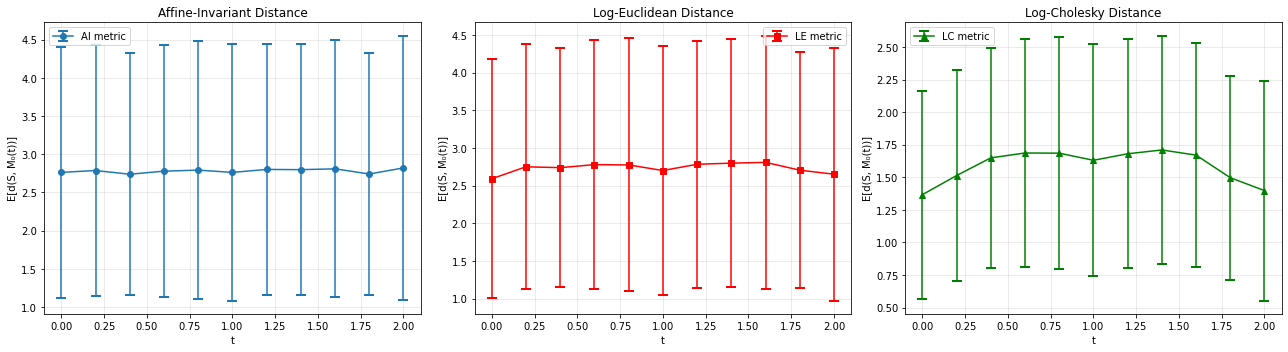


STATISTICAL ANALYSIS

--- NORMALITY TESTS (AI METRIC) ---
t=0.00: Shapiro-Wilk p=0.0000 ✗
t=0.20: Shapiro-Wilk p=0.0000 ✗
t=0.40: Shapiro-Wilk p=0.0000 ✗
t=0.60: Shapiro-Wilk p=0.0000 ✗
t=0.80: Shapiro-Wilk p=0.0000 ✗
t=1.00: Shapiro-Wilk p=0.0000 ✗
t=1.20: Shapiro-Wilk p=0.0000 ✗
t=1.40: Shapiro-Wilk p=0.0000 ✗
t=1.60: Shapiro-Wilk p=0.0000 ✗
t=1.80: Shapiro-Wilk p=0.0000 ✗
t=2.00: Shapiro-Wilk p=0.0000 ✗

--- NORMALITY TESTS (LE METRIC) ---
t=0.00: Shapiro-Wilk p=0.0000 ✗
t=0.20: Shapiro-Wilk p=0.0000 ✗
t=0.40: Shapiro-Wilk p=0.0000 ✗
t=0.60: Shapiro-Wilk p=0.0000 ✗
t=0.80: Shapiro-Wilk p=0.0000 ✗
t=1.00: Shapiro-Wilk p=0.0000 ✗
t=1.20: Shapiro-Wilk p=0.0000 ✗
t=1.40: Shapiro-Wilk p=0.0000 ✗
t=1.60: Shapiro-Wilk p=0.0000 ✗
t=1.80: Shapiro-Wilk p=0.0000 ✗
t=2.00: Shapiro-Wilk p=0.0000 ✗

--- NORMALITY TESTS (LOG-CHOLESKY METRIC) ---
t=0.00: Shapiro-Wilk p=0.0000 ✗
t=0.20: Shapiro-Wilk p=0.0000 ✗
t=0.40: Shapiro-Wilk p=0.0000 ✗
t=0.60: Shapiro-Wilk p=0.0000 ✗
t=0.80: Shapiro-Wilk p=0.

In [14]:
# Run the experiment
if __name__ == "__main__":
    # Test at several t values, focusing on t=0 and t=1
    t_test_values = list(np.linspace(0, 2, 11))  # 0, 0.1, ..., 1.0
    
    # Run experiment
    results = experiment_distance_independence(t_test_values, df=2, n_samples=5000)
    
    # Analyze results
    plot_results(results)
    statistical_test(results)

# HYPERBOLOID

INVESTIGATING WHY θ ∈ (0,π) EXCLUDES π


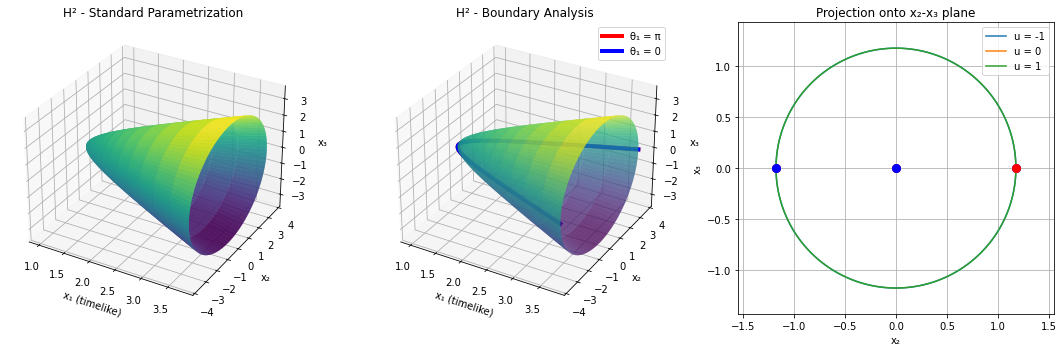

ANALYSIS OF θ₁ = π BOUNDARY:
At θ₁ = 0:  x₂ = sinh(u)·cos(0) = sinh(u)·1 = sinh(u)
            x₃ = sinh(u)·sin(0) = sinh(u)·0 = 0
At θ₁ = π:  x₂ = sinh(u)·cos(π) = sinh(u)·(-1) = -sinh(u)
            x₃ = sinh(u)·sin(π) = sinh(u)·0 = 0

CONCLUSION: Both θ₁ = 0 and θ₁ = π give the SAME curve!
This creates a coordinate singularity - the same physical point
is represented by two different coordinate values.

JACOBIAN ANALYSIS:
The full Jacobian for hyperbolic-spherical coordinates includes:
1. sinh^{d-1}(u) from the hyperbolic part
2. sin^{d-2}(θ₁)·sin^{d-3}(θ₂)·...·sin(θ_{d-2}) from spherical part



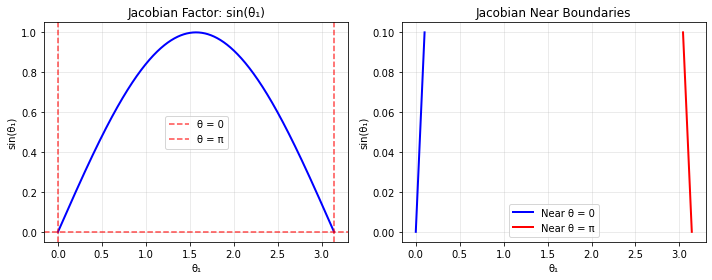

At θ₁ = 0 and θ₁ = π: sin(θ₁) = 0
This makes the Jacobian singular at these points!
That's why we exclude θ₁ = 0, π from the domain.

SUMMARY:
1. COORDINATE OVERLAP: θ₁ = 0 and θ₁ = π map to the same physical points
2. JACOBIAN SINGULARITY: sin(θ₁) = 0 at both θ₁ = 0 and θ₁ = π
3. SOLUTION: Exclude both boundaries to avoid:
   - Double-counting points
   - Singular Jacobian
   - Integration issues

This is analogous to spherical coordinates where we exclude
θ = 0, π to avoid the 'north/south pole problem'.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def hyperbolic_spherical_coords(u, theta, include_boundary=False):
    """
    Convert hyperbolic-spherical coordinates to Cartesian coordinates
    for the hyperboloid H^d
    
    Parameters:
    -----------
    u : float or array
        Radial hyperbolic coordinate
    theta : array
        Angular coordinates [theta_1, ..., theta_{d-1}]
        For d=2: theta = [theta_1] where theta_1 ∈ [0, 2π)
        For d=3: theta = [theta_1, theta_2] where theta_1 ∈ (0,π), theta_2 ∈ [0,2π)
    include_boundary : bool
        Whether to include theta = π for visualization
    """
    if len(theta) == 1:  # d = 2 case (2D hyperboloid in 3D space)
        theta_1 = theta[0]
        x1 = np.cosh(u)
        x2 = np.sinh(u) * np.cos(theta_1)
        x3 = np.sinh(u) * np.sin(theta_1)
        return np.array([x1, x2, x3])
    
    elif len(theta) == 2:  # d = 3 case (3D hyperboloid in 4D space)
        theta_1, theta_2 = theta[0], theta[1]
        x1 = np.cosh(u)
        x2 = np.sinh(u) * np.cos(theta_1)
        x3 = np.sinh(u) * np.sin(theta_1) * np.cos(theta_2)
        x4 = np.sinh(u) * np.sin(theta_1) * np.sin(theta_2)
        return np.array([x1, x2, x3, x4])
    
    else:
        raise ValueError("Only d=2 and d=3 cases implemented for visualization")

def plot_hyperboloid_2d():
    """Plot H^2 (2D hyperboloid in 3D space) and examine theta_1 = π"""
    fig = plt.figure(figsize=(15, 5))
    
    # Create coordinate grids
    u_vals = np.linspace(-2, 2, 30)
    theta1_vals = np.linspace(0, 2*np.pi, 50)
    U, Theta1 = np.meshgrid(u_vals, theta1_vals)
    
    # Compute coordinates
    X1 = np.cosh(U)
    X2 = np.sinh(U) * np.cos(Theta1)
    X3 = np.sinh(U) * np.sin(Theta1)
    
    # Plot 1: Normal parametrization (excluding boundaries)
    ax1 = fig.add_subplot(131, projection='3d')
    ax1.plot_surface(X1, X2, X3, alpha=0.7, cmap='viridis')
    ax1.set_title('H² - Standard Parametrization')
    ax1.set_xlabel('x₁ (timelike)')
    ax1.set_ylabel('x₂')
    ax1.set_zlabel('x₃')
    
    # Plot 2: Examine what happens at theta_1 = π
    ax2 = fig.add_subplot(132, projection='3d')
    
    # Plot the hyperboloid
    ax2.plot_surface(X1, X2, X3, alpha=0.5, cmap='viridis')
    
    # Highlight the curve where theta_1 = π
    u_line = np.linspace(-2, 2, 100)
    x1_pi = np.cosh(u_line)
    x2_pi = np.sinh(u_line) * np.cos(np.pi)  # cos(π) = -1
    x3_pi = np.sinh(u_line) * np.sin(np.pi)  # sin(π) = 0
    
    ax2.plot(x1_pi, x2_pi, x3_pi, 'r-', linewidth=4, label='θ₁ = π')
    
    # Highlight the curve where theta_1 = 0
    x2_0 = np.sinh(u_line) * np.cos(0)  # cos(0) = 1
    x3_0 = np.sinh(u_line) * np.sin(0)  # sin(0) = 0
    
    ax2.plot(x1_pi, x2_0, x3_0, 'b-', linewidth=4, label='θ₁ = 0')
    
    ax2.set_title('H² - Boundary Analysis')
    ax2.set_xlabel('x₁ (timelike)')
    ax2.set_ylabel('x₂')
    ax2.set_zlabel('x₃')
    ax2.legend()
    
    # Plot 3: 2D projection showing the issue
    ax3 = fig.add_subplot(133)
    
    # Project onto x2-x3 plane for different u values
    for u_val in [-1, 0, 1]:
        theta_full = np.linspace(0, 2*np.pi, 100)
        x2_circle = np.sinh(u_val) * np.cos(theta_full)
        x3_circle = np.sinh(u_val) * np.sin(theta_full)
        ax3.plot(x2_circle, x3_circle, label=f'u = {u_val}')
        
        # Mark the points at theta = 0 and theta = π
        ax3.plot(np.sinh(u_val), 0, 'ro', markersize=8)  # theta = 0
        ax3.plot(-np.sinh(u_val), 0, 'bo', markersize=8)  # theta = π
    
    ax3.set_title('Projection onto x₂-x₃ plane')
    ax3.set_xlabel('x₂')
    ax3.set_ylabel('x₃')
    ax3.legend()
    ax3.grid(True)
    ax3.axis('equal')
    
    plt.tight_layout()
    plt.show()
    
    # Analysis
    print("ANALYSIS OF θ₁ = π BOUNDARY:")
    print("="*50)
    print(f"At θ₁ = 0:  x₂ = sinh(u)·cos(0) = sinh(u)·1 = sinh(u)")
    print(f"            x₃ = sinh(u)·sin(0) = sinh(u)·0 = 0")
    print(f"At θ₁ = π:  x₂ = sinh(u)·cos(π) = sinh(u)·(-1) = -sinh(u)")
    print(f"            x₃ = sinh(u)·sin(π) = sinh(u)·0 = 0")
    print()
    print("CONCLUSION: Both θ₁ = 0 and θ₁ = π give the SAME curve!")
    print("This creates a coordinate singularity - the same physical point")
    print("is represented by two different coordinate values.")

def analyze_jacobian():
    """Analyze the Jacobian and see what happens at boundaries"""
    print("\nJACOBIAN ANALYSIS:")
    print("="*50)
    
    # For H^2, the Jacobian includes sinh^{d-1}(u) = sinh^1(u) = sinh(u)
    # But also terms from the spherical coordinates
    
    print("The full Jacobian for hyperbolic-spherical coordinates includes:")
    print("1. sinh^{d-1}(u) from the hyperbolic part")
    print("2. sin^{d-2}(θ₁)·sin^{d-3}(θ₂)·...·sin(θ_{d-2}) from spherical part")
    print()
    
    # For d=3 (so d-2=1), we need sin(θ₁) in the Jacobian
    theta_vals = np.linspace(0.001, np.pi-0.001, 1000)
    jacobian_factor = np.sin(theta_vals)
    
    plt.figure(figsize=(10, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(theta_vals, jacobian_factor, 'b-', linewidth=2)
    plt.axhline(y=0, color='r', linestyle='--', alpha=0.7)
    plt.axvline(x=0, color='r', linestyle='--', alpha=0.7, label='θ = 0')
    plt.axvline(x=np.pi, color='r', linestyle='--', alpha=0.7, label='θ = π')
    plt.xlabel('θ₁')
    plt.ylabel('sin(θ₁)')
    plt.title('Jacobian Factor: sin(θ₁)')
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    plt.subplot(1, 2, 2)
    # Show what happens near the boundaries
    theta_near_0 = np.linspace(0, 0.1, 100)
    theta_near_pi = np.linspace(np.pi-0.1, np.pi, 100)
    
    plt.plot(theta_near_0, np.sin(theta_near_0), 'b-', linewidth=2, label='Near θ = 0')
    plt.plot(theta_near_pi, np.sin(theta_near_pi), 'r-', linewidth=2, label='Near θ = π')
    plt.xlabel('θ₁')
    plt.ylabel('sin(θ₁)')
    plt.title('Jacobian Near Boundaries')
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    print("At θ₁ = 0 and θ₁ = π: sin(θ₁) = 0")
    print("This makes the Jacobian singular at these points!")
    print("That's why we exclude θ₁ = 0, π from the domain.")

# Run the analysis
if __name__ == "__main__":
    print("INVESTIGATING WHY θ ∈ (0,π) EXCLUDES π")
    print("="*60)
    
    plot_hyperboloid_2d()
    analyze_jacobian()
    
    print("\nSUMMARY:")
    print("="*50)
    print("1. COORDINATE OVERLAP: θ₁ = 0 and θ₁ = π map to the same physical points")
    print("2. JACOBIAN SINGULARITY: sin(θ₁) = 0 at both θ₁ = 0 and θ₁ = π")
    print("3. SOLUTION: Exclude both boundaries to avoid:")
    print("   - Double-counting points")
    print("   - Singular Jacobian")
    print("   - Integration issues")
    print()
    print("This is analogous to spherical coordinates where we exclude")
    print("θ = 0, π to avoid the 'north/south pole problem'.")
    

HYPERBOLOID VISUALIZATION
Parametrization: r > 0, u > 0, v₁,...,v_{d-3} ∈ (0,π), v_{d-2} ∈ (0,2π) \ {π}

NUMERICAL VERIFICATION:
For u = 1.0, v₁ = 0.785:
v₂ = 0:    x₃ = 0.8310, x₄ = 0.0000
v₂ = π:    x₃ = -0.8310, x₄ = 0.0000
v₂ = π/2:  x₃ = 0.0000, x₄ = 0.8310

→ All points are geometrically distinct!
→ No obvious reason to exclude π from coordinate perspective


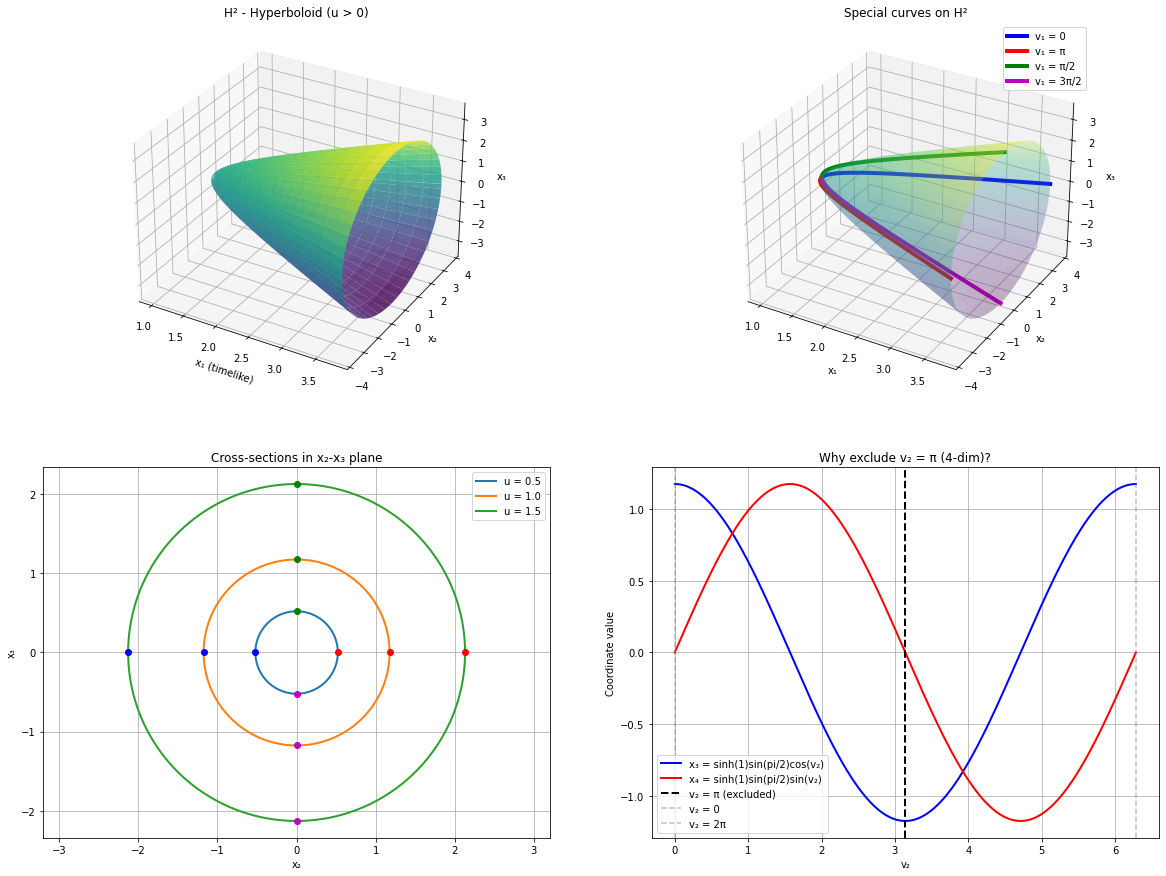

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def visualize_hyperboloid_parametrization():
    """
    Visualize the hyperboloid with the modified parametrization
    r > 0, u > 0, v₁,...,v_{d-3} ∈ (0,π), v_{d-2} ∈ (0,2π) \ {π}
    """
    print("HYPERBOLOID VISUALIZATION")
    print("="*50)
    print("Parametrization: r > 0, u > 0, v₁,...,v_{d-3} ∈ (0,π), v_{d-2} ∈ (0,2π) \\ {π}")
    print()
    
    fig = plt.figure(figsize=(20, 15))
    
    # For H² (2D hyperboloid in 3D space)
    # x₁ = cosh(u)
    # x₂ = sinh(u) * cos(v₁)
    # x₃ = sinh(u) * sin(v₁)
    # where u > 0 and v₁ ∈ [0, 2π) (but we'll examine what happens at π)
    
    # Create coordinate grids
    u_vals = np.linspace(0.1, 2, 30)  # u > 0
    v1_vals = np.linspace(0.001, 2*np.pi-0.001, 100)  # Full range including 
    U, V1 = np.meshgrid(u_vals, v1_vals)
    
    # Compute coordinates for H²
    X1 = np.cosh(U)
    X2 = np.sinh(U) * np.cos(V1)
    X3 = np.sinh(U) * np.sin(V1)
    
    # Plot 1: Full hyperboloid H²
    ax1 = fig.add_subplot(2, 2, 1, projection='3d')
    ax1.plot_surface(X1, X2, X3, alpha=0.8, cmap='viridis')
    ax1.set_title('H² - Hyperboloid (u > 0)')
    ax1.set_xlabel('x₁ (timelike)')
    ax1.set_ylabel('x₂')
    ax1.set_zlabel('x₃')
    
    # Plot 2: Show what happens at v₁ = π
    ax2 = fig.add_subplot(2, 2, 2, projection='3d')
    ax2.plot_surface(X1, X2, X3, alpha=0.3, cmap='viridis')
    
    # Highlight curves at special values
    u_line = np.linspace(0.1, 2, 100)
    
    # v₁ = 0
    x1_0 = np.cosh(u_line)
    x2_0 = np.sinh(u_line) * np.cos(0)    # cos(0) = 1
    x3_0 = np.sinh(u_line) * np.sin(0)    # sin(0) = 0
    ax2.plot(x1_0, x2_0, x3_0, 'b-', linewidth=4, label='v₁ = 0')
    
    # v₁ = π
    x2_pi = np.sinh(u_line) * np.cos(np.pi)  # cos(π) = -1
    x3_pi = np.sinh(u_line) * np.sin(np.pi)  # sin(π) = 0
    ax2.plot(x1_0, x2_pi, x3_pi, 'r-', linewidth=4, label='v₁ = π')
    
    # v₁ = π/2
    x2_pi2 = np.sinh(u_line) * np.cos(np.pi/2)  # cos(π/2) = 0
    x3_pi2 = np.sinh(u_line) * np.sin(np.pi/2)  # sin(π/2) = 1
    ax2.plot(x1_0, x2_pi2, x3_pi2, 'g-', linewidth=4, label='v₁ = π/2')

    # v₁ = 3π/2
    x2_pi34 = np.sinh(u_line) * np.cos(3*np.pi/2)  # cos(3π/2) = 0
    x3_pi34 = np.sinh(u_line) * np.sin(3*np.pi/2)  # sin(3π/2) = -1
    ax2.plot(x1_0, x2_pi34, x3_pi34, 'm', linewidth=4, label='v₁ = 3π/2')
    
    ax2.set_title('Special curves on H²')
    ax2.set_xlabel('x₁')
    ax2.set_ylabel('x₂')
    ax2.set_zlabel('x₃')
    ax2.legend()
    
    # Plot 3: Cross-sections at different u values
    ax3 = fig.add_subplot(2, 2, 3)
    for u_val in [0.5, 1.0, 1.5]:
        v1_circle = np.linspace(0, 2*np.pi, 1000)
        x2_circle = np.sinh(u_val) * np.cos(v1_circle)
        x3_circle = np.sinh(u_val) * np.sin(v1_circle)
        ax3.plot(x2_circle, x3_circle, label=f'u = {u_val}', linewidth=2)
        
        # Mark special points
        ax3.plot(np.sinh(u_val), 0, 'ro', markersize=6)  # v₁ = 0
        ax3.plot(0, np.sinh(u_val), 'go', markersize=6)   # v₁ = π/2
        ax3.plot(-np.sinh(u_val), 0, 'bo', markersize=6)  # v₁ = π
        ax3.plot(0, -np.sinh(u_val), 'mo', markersize=6)  # v₁ = 3π/2
    
    ax3.set_title('Cross-sections in x₂-x₃ plane')
    ax3.set_xlabel('x₂')
    ax3.set_ylabel('x₃')
    ax3.legend()
    ax3.grid(True)
    ax3.axis('equal')
    
    # For H³ case (3D hyperboloid in 4D space - project to 3D)
    # x₁ = cosh(u), x₂ = sinh(u)*cos(v₁), 
    # x₃ = sinh(u)*sin(v₁)*cos(v₂), x₄ = sinh(u)*sin(v₁)*sin(v₂)
    
    
    # Create some representative curves
    u_fixed = 1.0
    v1_fixed = np.pi/2
   
    
    # Plot 5: Analysis of the exclusion
    ax5 = fig.add_subplot(2,2, 4)
    
    v2_vals = np.linspace(0, 2*np.pi, 1000)
    # Show what points are covered
    x3_vs_v2 = np.sinh(u_fixed) * np.sin(v1_fixed) * np.cos(v2_vals)
    x4_vs_v2 = np.sinh(u_fixed) * np.sin(v1_fixed) * np.sin(v2_vals)
    
    ax5.plot(v2_vals, x3_vs_v2, 'b-', linewidth=2, label='x₃ = sinh(1)sin(pi/2)cos(v₂)')
    ax5.plot(v2_vals, x4_vs_v2, 'r-', linewidth=2, label='x₄ = sinh(1)sin(pi/2)sin(v₂)')
    ax5.axvline(x=np.pi, color='black', linestyle='--', linewidth=2, label='v₂ = π (excluded)')
    ax5.axvline(x=0, color='gray', linestyle='--', alpha=0.5, label='v₂ = 0')
    ax5.axvline(x=2*np.pi, color='gray', linestyle='--', alpha=0.5, label='v₂ = 2π')
    
    ax5.set_xlabel('v₂')
    ax5.set_ylabel('Coordinate value')
    ax5.set_title('Why exclude v₂ = π (4-dim)?')
    ax5.legend()
    ax5.grid(True)
    
    
    # Print numerical analysis
    print("NUMERICAL VERIFICATION:")
    print("="*30)
    u_test = 1.0
    v1_test = np.pi/4
    
    print(f"For u = {u_test}, v₁ = {v1_test:.3f}:")
    print(f"v₂ = 0:    x₃ = {np.sinh(u_test) * np.sin(v1_test) * np.cos(0):.4f}, x₄ = {np.sinh(u_test) * np.sin(v1_test) * np.sin(0):.4f}")
    print(f"v₂ = π:    x₃ = {np.sinh(u_test) * np.sin(v1_test) * np.cos(np.pi):.4f}, x₄ = {np.sinh(u_test) * np.sin(v1_test) * np.sin(np.pi):.4f}")
    print(f"v₂ = π/2:  x₃ = {np.sinh(u_test) * np.sin(v1_test) * np.cos(np.pi/2):.4f}, x₄ = {np.sinh(u_test) * np.sin(v1_test) * np.sin(np.pi/2):.4f}")
    print()
    print("→ All points are geometrically distinct!")
    print("→ No obvious reason to exclude π from coordinate perspective")

# Run the visualization
visualize_hyperboloid_parametrization()